
<center><font size=6>Sentiment Analysis with Word Embeddings and Transformers</center></font>




<center><img src="https://custom-images.strikinglycdn.com/res/hrscywv4p/image/upload/c_limit,fl_lossy,h_9000,w_1200,f_auto,q_auto/8103728/791986_833454.png" width="720"/></center>

<center><font size=5>Product Reviews Sentiment Analysis </center></font>


## **Problem Statement**

### **Business Context**

Customer reviews provide valuable insights into **customer satisfaction, product performance, usability, and value**. Since reviews are large in volume and unstructured, manual analysis is inefficient. **Sentiment analysis** helps businesses classify feedback as **positive, neutral, or negative**, enabling them to improve products, enhance customer satisfaction, and maintain competitiveness.

### **Objective**

The objective is to build a **sentiment analysis system** that classifies product reviews as **positive, neutral, or negative**. It will help businesses identify strengths, discover areas for improvement, address customer issues, and support **data-driven decisions** in product development, customer service, and brand communication.


### **Data Description**

* **Product ID:** Unique identifier for each product.
* **Product Review:** Customer feedback and opinions about the product.
* **Sentiment:** Classification of the review as **positive, negative, or neutral**.


## **Importing the necessary libraries**

In [2]:
import pandas as pd
import numpy as np
import warnings

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings('ignore')

In [1]:
# installing the libraries for transformers
!pip install sentence-transformers

## **Loading the dataset**

- Mount and Load the respective dataset from Google Drive using **`Pandas`** foe handling tabular data.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/GENAI-DATASET/Product_Reviews.csv")

## **Data Overview**

In [5]:
# to display the shape
data.shape

(1007, 3)

* The dataset has `1007` rows and `3` columns.

In [6]:
# to display the first 5 row
data.head()

,Product ID,Product Review,Sentiment
0,AVpe7AsMilAPnD_xQ78G,I initially had trouble deciding between the p...,POSITIVE
1,AVpe7AsMilAPnD_xQ78G,Allow me to preface this with a little history...,POSITIVE
2,AVpe7AsMilAPnD_xQ78G,I am enjoying it so far. Great for reading. Ha...,POSITIVE
3,AVpe7AsMilAPnD_xQ78G,I bought one of the first Paperwhites and have...,POSITIVE
4,AVpe7AsMilAPnD_xQ78G,I have to say upfront - I don't like coroporat...,POSITIVE


In [7]:
# to display the last 5 rows
data.tail()

,Product ID,Product Review,Sentiment
1002,AVpfo9ukilAPnD_xfhuj,This is not the same remote that I got for my ...,NEUTRAL
1003,AVpfo9ukilAPnD_xfhuj,I have had to change the batteries in this rem...,NEGATIVE
1004,AVpfo9ukilAPnD_xfhuj,"Remote did not activate, nor did it connect to...",NEGATIVE
1005,AVpfo9ukilAPnD_xfhuj,It does the job but is super over priced. I fe...,NEUTRAL
1006,AVpfo9ukilAPnD_xfhuj,I ordered this item to replace the one that no...,NEGATIVE


In [8]:
# checking for missing value
data.isnull().sum()

,0
Product ID,0
Product Review,0
Sentiment,0


- There's no missing value

In [9]:
# checking for duplicate values
data.duplicated().sum()

np.int64(2)

* There are 2 duplicate values in the dataset want drop that.

In [10]:
# dropping duplicate values & reseting the index of the dataframe
data = data.drop_duplicates().reset_index(drop=True)

data.duplicated().sum()

np.int64(0)

## **Exploratory Data Analysis (EDA)**


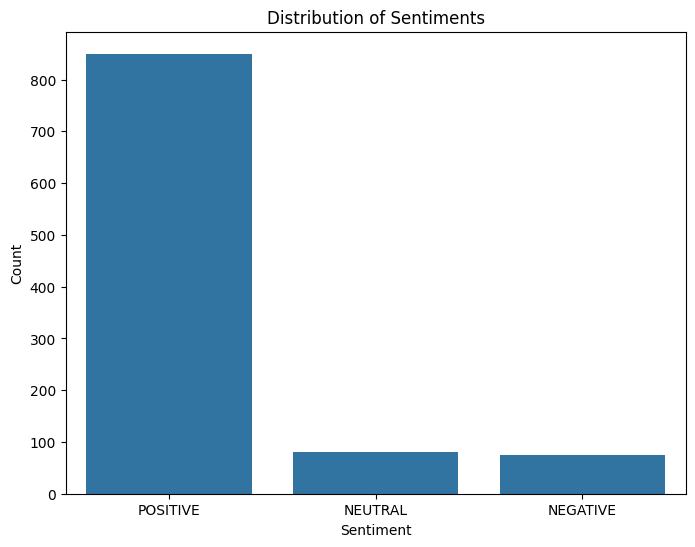

In [11]:
 # to distribution of sentiments in the dataset

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=data)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

> *Inference:*

* The dataset is highly imbalanced, with ~850 positive reviews and only ~75 each of neutral and negative reviews.


## **Defining the Sentence Transformer Model**

In [12]:
# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
print(type(data['Product Review']))

<class 'pandas.core.series.Series'>


In [14]:
# to generate embeddings for the `Product Review' in the dataset.

embedding_matrix = model.encode(
    data['Product Review'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [15]:
embedding_matrix.shape

(1005, 384)

## **Data Pre-processing**

### **Splitting the dataset**

In [16]:
# to split the data using embedding_matrix as X and data['Sentiment'] as y, with a 80:20 train-test ratio and maintain the class distribution.

X = embedding_matrix
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [17]:
# to check the shape of the training and testing sets to confirm the split.

print('Shape of training data:', X_train.shape)
print('Shape of testing data:', X_test.shape)
print('Shape of training labels:', y_train.shape)
print('Shape of testing labels:', y_test.shape)

Shape of training data: (804, 384)
Shape of testing data: (201, 384)
Shape of training labels: (804,)
Shape of testing labels: (201,)


## **Model Building - Transformers + ML**

### **Model Evaluation Criteria**

1. **Accuracy:** Measures the overall percentage of correct predictions.
2. **F1 Score:** Balances precision and recall, making it useful for **imbalanced sentiment classes**.


In [18]:
# to create an empty DataFrame called model_eval_results to store the accuracy and F1 scores for different models on both training and testing datasets.

model_eval_results = pd.DataFrame(columns=['Model', 'Train_Accuracy', 'Train_F1', 'Test_Accuracy', 'Test_F1'])

### **Random Forest Classifier**

In [19]:
# Building the model
rf_transformer = RandomForestClassifier(random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
# to evaluate the model on training and testing data and store in model-eval_result

from sklearn.metrics import f1_score

# to evaluate the model on training data
y_train_pred_rf = rf_transformer.predict(X_train)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf, average='weighted')

# to evaluate the model on testing data
y_test_pred_rf = rf_transformer.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='weighted')

# to store results
new_row_rf = pd.DataFrame([{
    'Model': 'RandomForest + Transformer',
    'Train_Accuracy': train_accuracy_rf,
    'Train_F1': train_f1_rf,
    'Test_Accuracy': test_accuracy_rf,
    'Test_F1': test_f1_rf
}])

model_eval_results = pd.concat([model_eval_results, new_row_rf], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.0,1.0,0.865672,0.818014


> *Inference:*

* **Random Forest with Transformer embeddings** achieved **100% training performance** and **86.5% test accuracy with an 81.8% F1 score**, indicating good generalization.


### **Gradient Boost Classifier**


In [21]:
# Building the model
gb_transformer = GradientBoostingClassifier(random_state = 42)

# Fitting on train data
gb_transformer.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [22]:
# to evaluate the model on training data
y_train_pred_gb = gb_transformer.predict(X_train)
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_f1_gb = f1_score(y_train, y_train_pred_gb, average='weighted')

# to evaluate the model on testing data
y_test_pred_gb = gb_transformer.predict(X_test)
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_f1_gb = f1_score(y_test, y_test_pred_gb, average='weighted')

# to store results
new_row_gb = pd.DataFrame([{
    'Model': 'GradientBoost + Transformer',
    'Train_Accuracy': train_accuracy_gb,
    'Train_F1': train_f1_gb,
    'Test_Accuracy': test_accuracy_gb,
    'Test_F1': test_f1_gb
}])

model_eval_results = pd.concat([model_eval_results, new_row_gb], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.000000,1.000000,0.865672,0.818014
1,GradientBoost + Transformer,0.998756,0.998752,0.840796,0.803252


> *Inference:*

* **Gradient Boosting with Transformer embeddings** achieved **84.07% test accuracy** and an **80.3% F1 score**, showing good performance but slightly below Random Forest.


**Note:**
- **Model performance can be improved** by exploring advanced techniques such as **XGBoost, SVM, neural networks, and fine-tuned transformer models**.


## **Final Model Selection**


* **Random Forest + Transformer** achieved **86.6% test accuracy** and **81.8% F1 score**, with a smaller generalization drop.
* **Gradient Boosting + Transformer** achieved **84.1% accuracy** and **80.3% F1 score**, with a larger performance drop.
* **Random Forest + Transformer** showed more consistent test performance and was selected for deployment.


# **Conclusion**

* Customer reviews were classified as **positive, neutral, or negative** using Transformer-based sentence embeddings.
* **Random Forest** performed best, achieving **86.1% accuracy and 81.4% F1 score**.
* The model can be improved by continuously adding **new reviews** to adapt to changing language and sentiment trends.
